In [ ]:
import time
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
text = """Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."""

chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

def decode(ints):
    return "".join(itos[i] for i in ints)

data = torch.tensor(encode(text), dtype=torch.long)
print("Total characters:", len(text))
print("Vocab size:", vocab_size)


Total characters: 2391
Vocab size: 45


In [ ]:
class CharWindowDataset(Dataset):

    def __init__(self, data, seq_len):
        self.seq_len = seq_len
        self.data = data
        self.num_samples = len(data) - seq_len

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x = self.data[idx: idx + self.seq_len]
        y = self.data[idx + self.seq_len]
        return x, y


def make_loaders(data, seq_len, val_frac=0.1, batch_size=64):
    full_ds = CharWindowDataset(data, seq_len)
    n_val = max(1, int(len(full_ds) * val_frac))
    n_train = len(full_ds) - n_val
    train_ds, val_ds = torch.utils.data.random_split(
        full_ds, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


In [ ]:
class CharTransformer(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=64, n_heads=4, n_layers=2,
                 d_ff=128, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, activation="relu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)


        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        self.register_buffer("causal_mask", mask)

    def forward(self, x):

        B, T = x.shape
        positions = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T)
        h = self.token_emb(x) + self.pos_emb(positions)
        h = self.dropout(h)
        h = self.encoder(h, mask=self.causal_mask[:T, :T])
        last_hidden = h[:, -1, :]
        logits = self.fc_out(last_hidden)
        return logits

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


In [ ]:
def estimate_transformer_flops(seq_len, d_model, n_heads, n_layers, d_ff):

    attn_proj_flops = 4 * seq_len * d_model * d_model
    attn_score_flops = 2 * seq_len * seq_len * d_model
    ffn_flops = 2 * seq_len * d_model * d_ff * 2
    per_layer = attn_proj_flops + attn_score_flops + ffn_flops
    return per_layer * n_layers


In [ ]:
def train_model(model, train_loader, val_loader, epochs=30, lr=3e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_accuracies = [], []
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss, n_batches = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        avg_train_loss = total_loss / n_batches
        train_losses.append(avg_train_loss)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                preds = logits.argmax(dim=-1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        val_accuracies.append(val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | train_loss={avg_train_loss:.4f} | val_acc={val_acc:.4f}")

    training_time = time.time() - start_time
    return train_losses, val_accuracies, training_time


In [ ]:
seq_lengths = [10, 20, 30]
results = {}

D_MODEL, N_HEADS, N_LAYERS, D_FF, EPOCHS = 64, 4, 2, 128, 30

for seq_len in seq_lengths:
    print(f"\n=== Training Transformer | seq_len={seq_len} ===")
    train_loader, val_loader = make_loaders(data, seq_len)

    model = CharTransformer(
        vocab_size=vocab_size, seq_len=seq_len,
        d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, d_ff=D_FF,
    )
    n_params = model.count_params()
    flops = estimate_transformer_flops(seq_len, D_MODEL, N_HEADS, N_LAYERS, D_FF)

    train_losses, val_accs, train_time = train_model(model, train_loader, val_loader, epochs=EPOCHS)

    results[seq_len] = {
        "train_losses": train_losses,
        "val_accuracies": val_accs,
        "final_train_loss": train_losses[-1],
        "final_val_acc": val_accs[-1],
        "training_time_sec": train_time,
        "num_params": n_params,
        "approx_flops_per_forward": flops,
    }
    print(f"  -> final_train_loss={train_losses[-1]:.4f} | final_val_acc={val_accs[-1]:.4f} "
          f"| time={train_time:.1f}s | params={n_params:,} | approx_flops={flops:,}")



=== Training Transformer | seq_len=10 ===
  Epoch   1/30 | train_loss=3.0355 | val_acc=0.2353
  Epoch   5/30 | train_loss=2.0618 | val_acc=0.4244
  Epoch  10/30 | train_loss=1.5972 | val_acc=0.4496
  Epoch  15/30 | train_loss=1.3323 | val_acc=0.4370
  Epoch  20/30 | train_loss=1.1350 | val_acc=0.4454
  Epoch  25/30 | train_loss=1.0274 | val_acc=0.4244
  Epoch  30/30 | train_loss=0.9120 | val_acc=0.4118
  -> final_train_loss=0.9120 | final_val_acc=0.4118 | time=8.1s | params=73,389 | approx_flops=1,008,640

=== Training Transformer | seq_len=20 ===
  Epoch   1/30 | train_loss=3.0572 | val_acc=0.2574
  Epoch   5/30 | train_loss=2.0746 | val_acc=0.3586
  Epoch  10/30 | train_loss=1.6631 | val_acc=0.4304
  Epoch  15/30 | train_loss=1.4153 | val_acc=0.4262
  Epoch  20/30 | train_loss=1.1896 | val_acc=0.4388
  Epoch  25/30 | train_loss=1.0438 | val_acc=0.4346
  Epoch  30/30 | train_loss=0.9234 | val_acc=0.4262
  -> final_train_loss=0.9234 | final_val_acc=0.4262 | time=6.6s | params=74,029 |

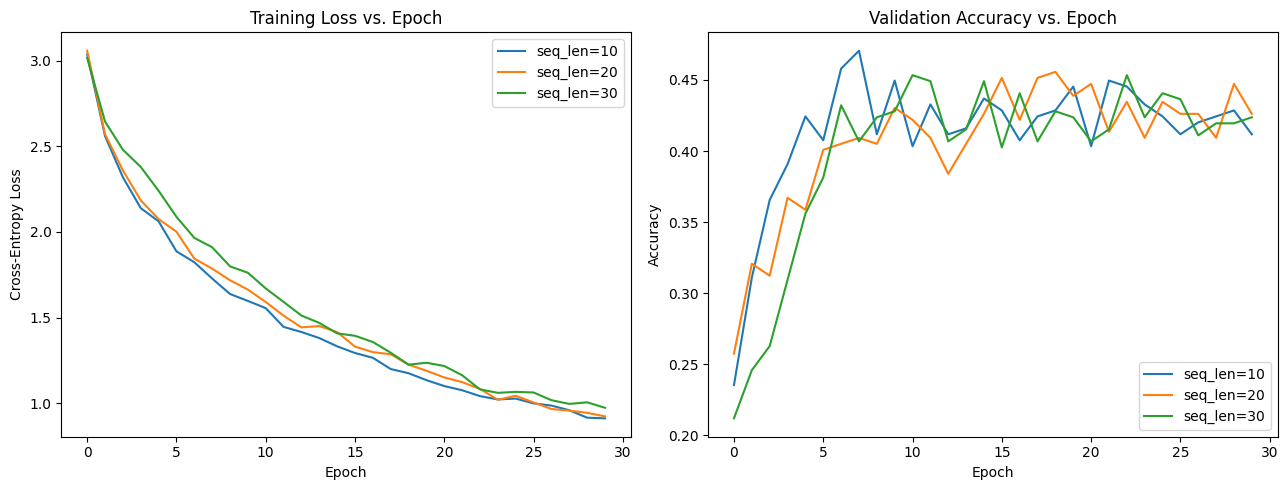

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for seq_len in seq_lengths:
    axes[0].plot(results[seq_len]["train_losses"], label=f"seq_len={seq_len}")
    axes[1].plot(results[seq_len]["val_accuracies"], label=f"seq_len={seq_len}")

axes[0].set_title("Training Loss vs. Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

axes[1].set_title("Validation Accuracy vs. Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("transformer_seqlen_comparison.png", dpi=150)
plt.show()


In [ ]:
import pandas as pd

summary_rows = []
for seq_len in seq_lengths:
    r = results[seq_len]
    summary_rows.append({
        "Sequence Length": seq_len,
        "Final Train Loss": round(r["final_train_loss"], 4),
        "Final Val Accuracy": round(r["final_val_acc"], 4),
        "Training Time (s)": round(r["training_time_sec"], 2),
        "Num Parameters": r["num_params"],
        "Approx. FLOPs / forward pass": r["approx_flops_per_forward"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Sequence Length,Final Train Loss,Final Val Accuracy,Training Time (s),Num Parameters,Approx. FLOPs / forward pass
0,10,0.9120,0.4118,8.11,73389,1008640
1,20,0.9234,0.4262,6.56,74029,2068480
2,30,0.9736,0.4237,7.44,74669,3179520
